# Analysis

scrape information from the https://en.wikipedia.org/wiki/List_of_Mayday_episodes


## Mount the drive and set the working directory

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

import os

os.chdir('/content/drive/My Drive/GU/practice/4_project/')

Mounted at /content/drive/


In [2]:
!pwd

/content/drive/My Drive/GU/practice/4_project


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from collections import Counter

In [4]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:

def load_data(file_path):
    """
    Task: Load the CSV file into a Pandas DataFrame.

    Input parameters:
        file_path (str): Path to the CSV file.

    Output:
        pd.DataFrame: Loaded dataset.
    """
    try:
        df = pd.read_csv(file_path)
        print("Data loaded successfully!")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def clean_data_0(df):
    """
    Task: Clean the dataset by handling missing values, duplicates, and formatting issues.

    Input parameters:
        df (pd.DataFrame): Input dataset.

    Output:
        pd.DataFrame: Cleaned dataset.
    """
    # Drop duplicates
    df = df.drop_duplicates()

    # Handle missing values (if any)
    df = df.dropna(subset=['Description', 'Incident'])

    # Extract year from 'Original release date'
    df['Year'] = df['Original release date'].str.extract(r'(\d{4})').astype(int)

    return df



def analyze_fatalities(df):
    """
    Task: Analyze fatalities by extracting numbers from descriptions.

    Input parameters:
        df (pd.DataFrame): Input dataset.

    Output:
        None (plots a histogram of fatalities).
    """

    plt.figure(figsize=(10, 5))
    sns.histplot(df['fatality_count'].dropna(), bins=20, kde=True, color='purple')
    plt.title('Distribution of Fatalities in Mayday Episodes')
    plt.xlabel('Number of Fatalities')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def generate_word_cloud(df):
    """
    Task: Generate a word cloud from episode descriptions to identify common themes.

    Input parameters:
        df (pd.DataFrame): Input dataset.

    Output:
        None (displays a word cloud).
    """
    text = " ".join(desc for desc in df['Description'])

    # Preprocess text (remove stopwords, punctuation)
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text.lower())
    words = [word for word in words if word.isalpha() and word not in stop_words]

    word_freq = Counter(words)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Common Themes in Mayday Episodes (Word Cloud)')
    plt.show()

def analyze_accident_causes(df):
    """
    Task: Extract and analyze common causes of accidents from descriptions.

    Input parameters:
        df (pd.DataFrame): Input dataset with 'Description' column.

    Output:
        pd.DataFrame: Original DataFrame with new 'accident_cause' column.
        (Also plots a bar chart of top causes)
    """
    # Define keywords for common causes (with priority order)
    cause_patterns = [
        ('sabotage', r'bomb|hijack|terror|sabotage'),
        ('weather', r'weather|storm|fog|wind shear|microburst'),
        ('mechanical failure', r'mechanical failure|engine failure|structural failure|design flaw'),
        ('pilot error', r'pilot error|crew error|captain error|miscommunication|fatigue'),
        ('maintenance', r'maintenance|repair|improper fix|faulty repair'),
        ('unknown', r'.')  # Default if no other pattern matches
    ]

    # Assign causes based on priority (first match wins)
    df['accident_cause'] = 'unknown'
    for cause, pattern in cause_patterns[:-1]:  # Skip 'unknown' initially
        mask = df['Description'].str.contains(pattern, case=False, regex=True)
        df.loc[mask, 'accident_cause'] = cause

    # Count causes for visualization
    cause_counts = df['accident_cause'].value_counts()

    # Plot
    plt.figure(figsize=(10, 5))
    cause_counts.plot(kind='bar', color='teal')
    plt.title('Common Causes of Accidents in Mayday Episodes')
    plt.xlabel('Cause')
    plt.ylabel('Number of Episodes')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    return df


def extract_fatality_count(description):
    """
    Extracts fatality count from a description string using regex.
    Cases covered:
      - "killing 128 people" → 128
      - "killing all 70 on board" → 70
      - "killing nine people" → 9
      - "no loss of life" → 0
      - "all 88 on board died" → 88
    """
    # Case 1: Explicit numbers (e.g., "killing 128 people")
    match = re.search(r'killing (\d+) (?:people|passengers|on board|occupants)', description, re.IGNORECASE)
    if match:
        return int(match.group(1))

    # Case 2: "killing all X on board"
    match = re.search(r'(?:killing|killed) all (\d+) (?:on board|passengers|people)', description, re.IGNORECASE)
    if match:
        return int(match.group(1))

    # Case 3: Textual numbers (e.g., "killing nine people")
    text_numbers = {
        'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
        'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
        'eleven': 11, 'twelve': 12, 'thirteen': 13, 'fourteen': 14, 'fifteen': 15,
        'sixteen': 16, 'seventeen': 17, 'eighteen': 18, 'nineteen': 19, 'twenty': 20
    }
    for word, num in text_numbers.items():
        if re.search(fr'killing {word} (?:people|passengers)', description, re.IGNORECASE):
            return num

    # Case 4: "no (more) loss of life" → 0
    if re.search(r'no (?:more )?loss of life|no fatalities|no one died', description, re.IGNORECASE):
        return 0

    # Case 5: "all on board died" (assume worst case, e.g., "all 100 on board" → extract if number exists)
    if re.search(r'all (?:(\d+) )?(?:on board|passengers|crew) (?:died|perished|were killed)', description, re.IGNORECASE):
        return int(match.group(1)) if match.group(1) else None  # None if count is unspecified

    return None  # If no pattern matches

def clean_data(df):
    """
    Task: Clean the dataset and extract:
        - Fatality count from 'Description' as 'fatality_count'
        - Incident date as 'incident_date'
        - Error type ('mechanical' or 'human error') as 'error_type'
    """
    df = df.copy()

    # Extract fatality count
    df['fatality_count'] = df['Description'].apply(extract_fatality_count).fillna(0).astype(int)

    # Extract incident date (e.g., "On 24 February 1989,...")
    df['incident_date'] = df['Description'].str.extract(r'On (\d{1,2} \w+ \d{4})')


    return df



def analyze_incident_trends(df):
    """
    Task: Analyze trends in accidents by year based on incident dates.

    Input parameters:
        df (pd.DataFrame): Input dataset with 'incident_date' column.

    Output:
        None (plots a line chart of accidents per year).
    """
    # Convert incident_date to datetime (handling day-month-year format)
    df['incident_date'] = pd.to_datetime(df['incident_date'], format='%d %B %Y', errors='coerce')

    # Extract year from incident_date
    df['incident_year'] = df['incident_date'].dt.year

    # Count accidents per year
    accidents_per_year = df['incident_year'].value_counts().sort_index()

    # Plot
    plt.figure(figsize=(12, 6))
    accidents_per_year.plot(kind='line', marker='o', color='royalblue', linewidth=2)

    plt.title('Aviation Accidents Covered in Mayday (by Incident Year)', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Accidents', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Improve x-axis labels
    min_year = int(accidents_per_year.index.min())
    max_year = int(accidents_per_year.index.max())
    plt.xticks(
        range(min_year, max_year+1, 5),
        rotation=45,
        ha='right'
    )

    plt.tight_layout()
    plt.show()

In [6]:
file_path = 'mayday_csv.csv'
df_raw = load_data(file_path)
df_raw.head()

Data loaded successfully!


,No.overall,No. inseries,Title,Incident,Original release date,Description
0,1,1,"""Unlocking Disaster""",United Airlines Flight 811,10 September 2003 (2003-09-10),"On 24 February 1989, part of the right-side fu..."
1,2,2,"""Racing the Storm""",American Airlines Flight 1420,3 September 2003 (2003-09-03),"On 1 June 1999, American Airlines Flight 1420 ..."
2,3,3,"""Fire on Board""",Swissair Flight 111,22 October 2003 (2003-10-22),"On 2 September 1998, a fire breaks out on Swis..."
3,4,4,"""Flying Blind""",Aeroperú Flight 603,17 September 2003 (2003-09-17),"On 2 October 1996, shortly after take off, the..."
4,5,5,"""Cutting Corners""",Alaska Airlines Flight 261,15 October 2003 (2003-10-15),"On 31 January 2000, Alaska Airlines Flight 261..."


## Data cleaing:
- removing duplicates
- handling missing values
- extracting the year from the release date

In [7]:
df_mayday = clean_data(df_raw)
df_mayday.head()

,No.overall,No. inseries,Title,Incident,Original release date,Description,fatality_count,incident_date
0,1,1,"""Unlocking Disaster""",United Airlines Flight 811,10 September 2003 (2003-09-10),"On 24 February 1989, part of the right-side fu...",0,24 February 1989
1,2,2,"""Racing the Storm""",American Airlines Flight 1420,3 September 2003 (2003-09-03),"On 1 June 1999, American Airlines Flight 1420 ...",11,1 June 1999
2,3,3,"""Fire on Board""",Swissair Flight 111,22 October 2003 (2003-10-22),"On 2 September 1998, a fire breaks out on Swis...",0,2 September 1998
3,4,4,"""Flying Blind""",Aeroperú Flight 603,17 September 2003 (2003-09-17),"On 2 October 1996, shortly after take off, the...",70,2 October 1996
4,5,5,"""Cutting Corners""",Alaska Airlines Flight 261,15 October 2003 (2003-10-15),"On 31 January 2000, Alaska Airlines Flight 261...",88,31 January 2000


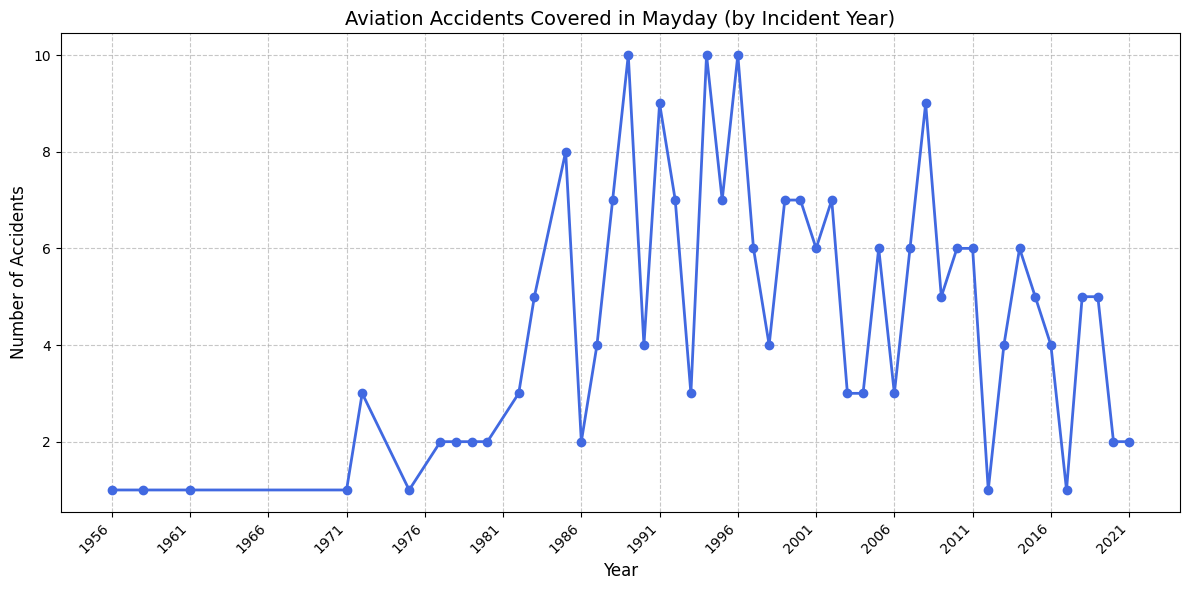

In [8]:

analyze_incident_trends(df_mayday)

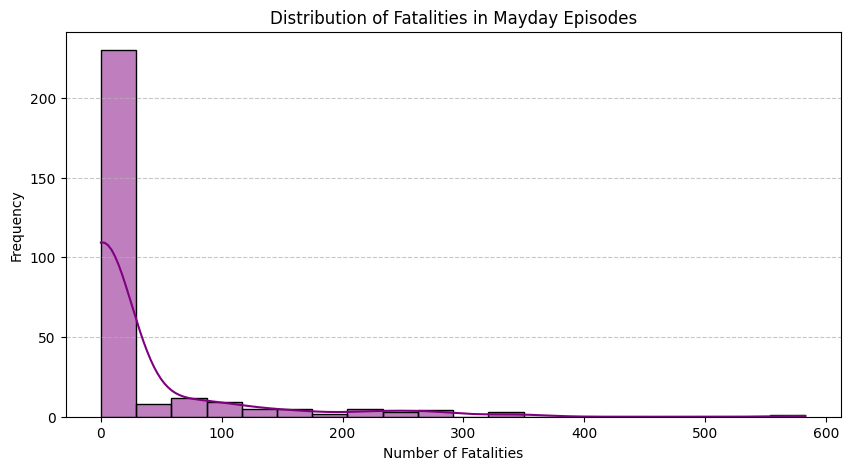

In [9]:

analyze_fatalities(df_mayday)

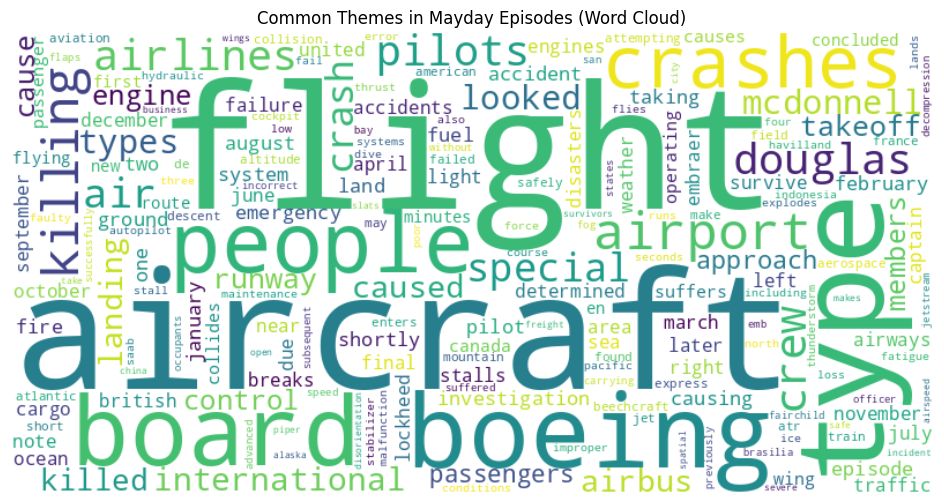

In [10]:
generate_word_cloud(df_mayday)

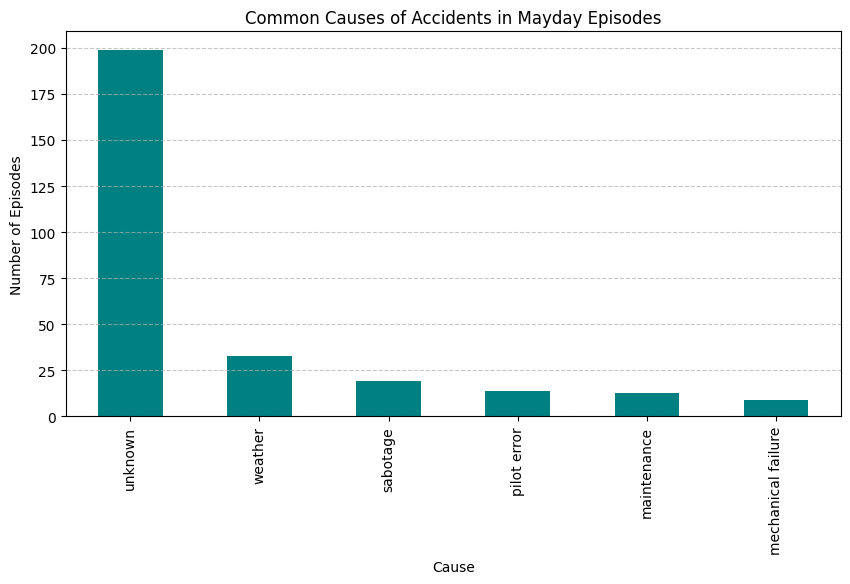

,No.overall,No. inseries,Title,Incident,Original release date,Description,fatality_count,incident_date,incident_year,accident_cause
0,1,1,"""Unlocking Disaster""",United Airlines Flight 811,10 September 2003 (2003-09-10),"On 24 February 1989, part of the right-side fu...",0,1989-02-24,1989.0,sabotage
1,2,2,"""Racing the Storm""",American Airlines Flight 1420,3 September 2003 (2003-09-03),"On 1 June 1999, American Airlines Flight 1420 ...",11,1999-06-01,1999.0,weather
2,3,3,"""Fire on Board""",Swissair Flight 111,22 October 2003 (2003-10-22),"On 2 September 1998, a fire breaks out on Swis...",0,1998-09-02,1998.0,unknown
3,4,4,"""Flying Blind""",Aeroperú Flight 603,17 September 2003 (2003-09-17),"On 2 October 1996, shortly after take off, the...",70,1996-10-02,1996.0,maintenance
4,5,5,"""Cutting Corners""",Alaska Airlines Flight 261,15 October 2003 (2003-10-15),"On 31 January 2000, Alaska Airlines Flight 261...",88,2000-01-31,2000.0,unknown


In [11]:
analyze_accident_causes(df_mayday)
df_mayday.head()

In [12]:
df_mayday.to_csv('mayday_data.csv')

# Lets do some Machine learning

In [19]:
df_mayday.columns

Index(['No.overall', 'No. inseries', 'Title', 'Incident',
       'Original release date', 'Description', 'fatality_count',
       'incident_date', 'incident_year', 'accident_cause'],
      dtype='object')

In [23]:
# how many different kinds of accident_cause

print(df_mayday['accident_cause'].unique())

['sabotage' 'weather' 'unknown' 'maintenance' 'pilot error'
 'mechanical failure']


# Deine ML pipeline
- preprocess data
- model  training
- evaluation

In [45]:
# value count of accident_cause

df_mayday['accident_cause'].value_counts()

,count
accident_cause,
weather,33
sabotage,19
pilot error,14
maintenance,13
mechanical failure,9


In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from scipy.sparse import hstack
import numpy as np

# Step 1: Clean DataFrame
df = df_mayday.dropna(subset=['incident_year', 'accident_cause', 'Description']).copy()
df.loc[:, 'incident_year'] = df['incident_year'].astype(int)

# Step 2: Features and Target
X_text = df['Description']
X_num = df[['fatality_count', 'incident_year']]
y = df['accident_cause']

# Step 3: Vectorize text
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
X_text_vec = tfidf.fit_transform(X_text)

# Step 4: Scale numerical data
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Step 5: Combine text and numeric features
X_combined = hstack([X_text_vec, X_num_scaled])


# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# Step 7: Train classifier
clf = RandomForestClassifier(random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# Step 8: Predict and evaluate
y_pred = clf.predict(X_test)
#print("Classification Report:\n", classification_report(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


Classification Report:
                     precision    recall  f1-score   support

       maintenance       1.00      0.50      0.67         2
mechanical failure       0.00      0.00      0.00         2
       pilot error       1.00      0.25      0.40         4
          sabotage       0.00      0.00      0.00         3
           weather       0.33      1.00      0.50         4

          accuracy                           0.40        15
         macro avg       0.47      0.35      0.31        15
      weighted avg       0.49      0.40      0.33        15



<Figure size 1000x700 with 0 Axes>

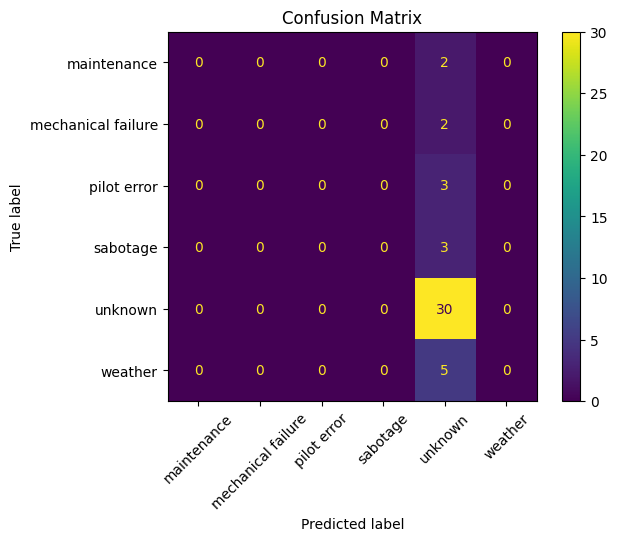

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 7))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


## Lets check by removing the unknonws

In [44]:
df_mayday_original = df_mayday.copy() # lets save the orginal
df_mayday['accident_cause'].value_counts()

,count
accident_cause,
weather,33
sabotage,19
pilot error,14
maintenance,13
mechanical failure,9


In [50]:

# Step 1: Clean DataFrame and fix the warning
df = df_mayday.dropna(subset=['incident_year', 'accident_cause', 'Description']).copy()
df.loc[:, 'incident_year'] = df['incident_year'].astype(int)

# Step 2: Features and Target
X_text = df['Description']
X_num = df[['fatality_count', 'incident_year']]
y = df['accident_cause']

# Step 3: Vectorize text
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
X_text_vec = tfidf.fit_transform(X_text)

# Step 4: Scale numerical data
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Step 5: Combine text and numeric features
X_combined = hstack([X_text_vec, X_num_scaled])


# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# Step 7: Train classifier
clf = RandomForestClassifier(random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# Step 8: Predict and evaluate
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


Classification Report:
                     precision    recall  f1-score   support

       maintenance       1.00      0.50      0.67         2
mechanical failure       0.00      0.00      0.00         2
       pilot error       1.00      0.25      0.40         4
          sabotage       0.00      0.00      0.00         3
           weather       0.33      1.00      0.50         4

          accuracy                           0.40        15
         macro avg       0.47      0.35      0.31        15
      weighted avg       0.49      0.40      0.33        15



<Figure size 1000x700 with 0 Axes>

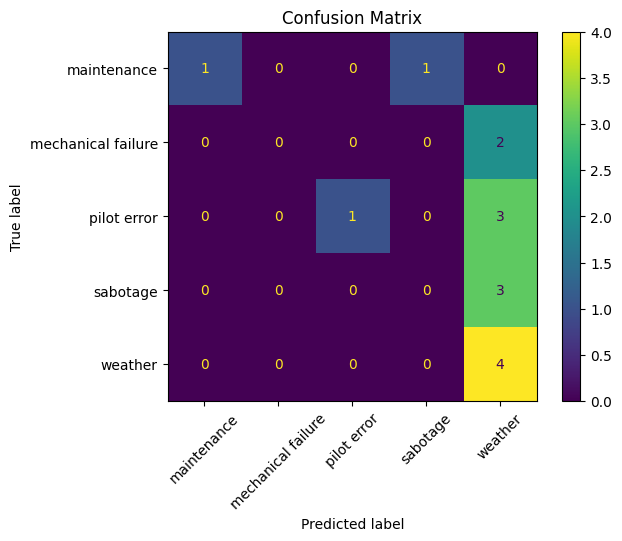

In [42]:
plt.figure(figsize=(10, 7))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

### Lets do the data balancing
 - SMOTE (`smote = SMOTE(random_state=42)`) performs **oversampling** by generating synthetic samples for the minority class to balance the dataset.


In [46]:

# Step 6: Apply SMOTE for balancing
smote = SMOTE(random_state=42) #
X_resampled, y_resampled = smote.fit_resample(X_combined, y)

# Step 7: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Step 8: Train classifier
clf = RandomForestClassifier(random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# Step 9: Predict and evaluate
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
                     precision    recall  f1-score   support

       maintenance       1.00      0.91      0.95        11
mechanical failure       1.00      0.67      0.80         6
       pilot error       0.75      1.00      0.86         3
          sabotage       1.00      0.43      0.60         7
           weather       0.40      1.00      0.57         4

          accuracy                           0.77        31
         macro avg       0.83      0.80      0.76        31
      weighted avg       0.90      0.77      0.78        31



### Lets plot the Confusion Matrix Heatmap

<Figure size 1000x700 with 0 Axes>

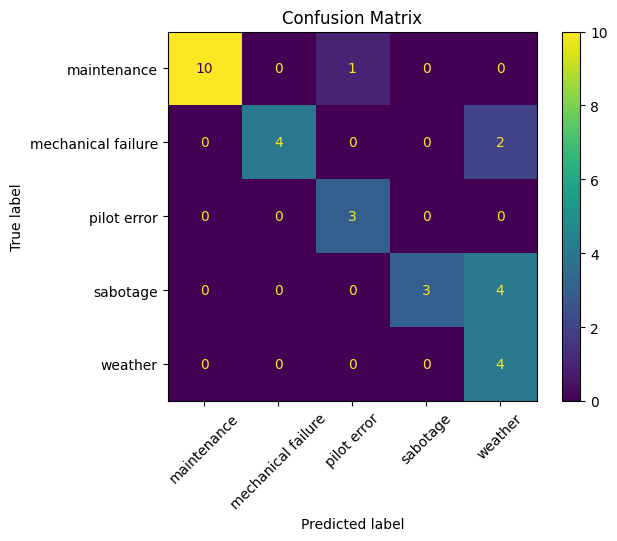

In [47]:

plt.figure(figsize=(10, 7))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
